In [15]:
import numpy as np
import pandas as pd

from numpy import array
from numpy import asarray
from pandas import DataFrame
from pandas import concat

# Gráficos
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from matplotlib import pyplot
plt.style.use('fivethirtyeight')
plt.rcParams['lines.linewidth'] = 1.5
%matplotlib inline

# Modelación y pronóstico
#Random Forest:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
##Regressor:
from skforecast.ForecasterAutoreg import ForecasterAutoreg
from skforecast.ForecasterAutoregCustom import ForecasterAutoregCustom
from skforecast.ForecasterAutoregDirect import ForecasterAutoregDirect
from skforecast.model_selection import grid_search_forecaster
from skforecast.model_selection import backtesting_forecaster
from skforecast.utils import save_forecaster
from skforecast.utils import load_forecaster

from joblib import dump, load

from datetime import datetime
from math import sqrt
# Configuración de warnings:
import warnings
warnings.filterwarnings('once')

from pandas_datareader import data as pdr
import yfinance as yf

import warnings
warnings.filterwarnings('ignore')

In [16]:
#Descargar datos
start = '2016-05-01'
end = '2018-01-28'
meta = yf.download("META", start, end)['Close']
meta.head()

[*********************100%***********************]  1 of 1 completed


Ticker,META
Date,
2016-05-02,117.646767
2016-05-03,116.515640
2016-05-04,117.140739
2016-05-05,116.892685
2016-05-06,118.559601


In [17]:
#Pasar a data frame los datos
df= pd.DataFrame(meta)
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 439 entries, 2016-05-02 to 2018-01-26
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   META    439 non-null    float64
dtypes: float64(1)
memory usage: 6.9 KB


In [18]:
#Pasar el data frame a un objeto de tiempo de pandas
dataindex= pd.to_datetime(df.index)
dataindex

DatetimeIndex(['2016-05-02', '2016-05-03', '2016-05-04', '2016-05-05',
               '2016-05-06', '2016-05-09', '2016-05-10', '2016-05-11',
               '2016-05-12', '2016-05-13',
               ...
               '2018-01-12', '2018-01-16', '2018-01-17', '2018-01-18',
               '2018-01-19', '2018-01-22', '2018-01-23', '2018-01-24',
               '2018-01-25', '2018-01-26'],
              dtype='datetime64[ns]', name='Date', length=439, freq=None)

In [19]:
#formato de fecha con periodiciadad diaria a la serie.
df['Date'] = pd.to_datetime(df.index, format='%Y-%m-%d')    
df = df.set_index('Date')
df = df.asfreq('B')
df = df.sort_index()
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 455 entries, 2016-05-02 to 2018-01-26
Freq: B
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   META    439 non-null    float64
dtypes: float64(1)
memory usage: 7.1 KB


In [20]:
## Imputamos algún valor faltante con el valor anterior.
df.fillna(method='bfill', inplace=True)

In [21]:
#verificar si valores faltantes.
print(f'Number of rows with missing values: {df.isnull().any(axis=1).mean()}')

Number of rows with missing values: 0.0


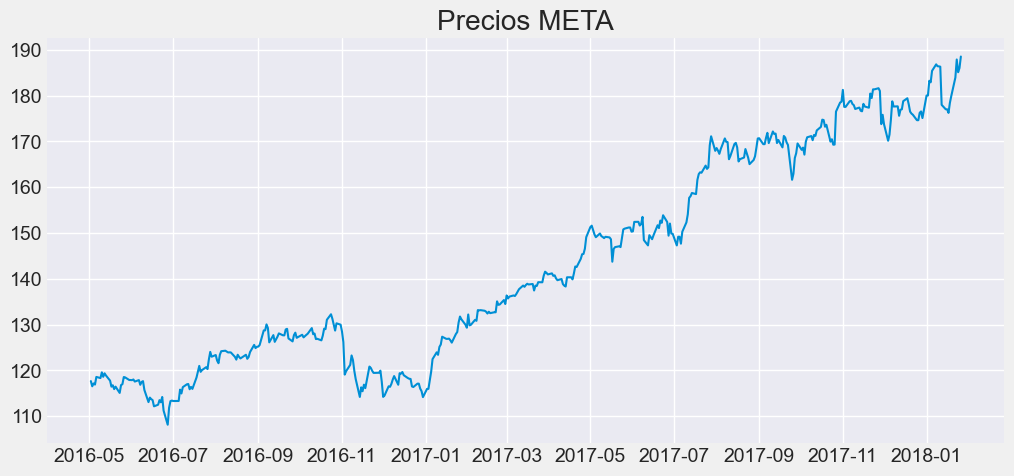

In [22]:
#Graficar datos
plt.figure(figsize=(11, 5))
plt.style.use('seaborn-v0_8-darkgrid')
plt.title('Precios META')
plt.plot(df)

In [23]:
# Partición de datos en entrenamiento 95% y prueba 5%
split_percent = 0.05
steps = int(len(df) * split_percent)
data_train = df[:-steps]
data_test  = df[-steps:]
print(f"Train dates : {data_train.index.min()} --- {data_train.index.max()}  (n={len(data_train)})")
print(f"Test dates  : {data_test.index.min()} --- {data_test.index.max()}  (n={len(data_test)})")

#Así también para las fechas:
date_train = dataindex[:-steps]
date_test = dataindex[-steps:]


Train dates : 2016-05-02 00:00:00 --- 2017-12-27 00:00:00  (n=433)
Test dates  : 2017-12-28 00:00:00 --- 2018-01-26 00:00:00  (n=22)


In [24]:
data_train.head()

Ticker,META
Date,
2016-05-02,117.646767
2016-05-03,116.515640
2016-05-04,117.140739
2016-05-05,116.892685
2016-05-06,118.559601


In [25]:
#Modelo RF
regressor = RandomForestRegressor(max_depth=10, n_estimators=100, random_state=123)
forecaster = ForecasterAutoreg(
                regressor = regressor,
                lags = 10
                )

forecaster.fit(y=data_train['META'])
forecaster

ForecasterAutoreg 
Regressor: RandomForestRegressor(max_depth=10, random_state=123) 
Lags: [ 1  2  3  4  5  6  7  8  9 10] 
Transformer for y: None 
Transformer for exog: None 
Window size: 10 
Weight function included: False 
Differentiation order: None 
Exogenous included: False 
Type of exogenous variable: None 
Exogenous variables names: None 
Training range: [Timestamp('2016-05-02 00:00:00'), Timestamp('2017-12-27 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: B 
Regressor parameters: {'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': 10, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': 123, 'verbose': 0, 'warm_start': False} 
fit_kwargs: {} 
Creation date: 2026-05-10 17:10:26 
Last fit date: 2026-05-10 17:10:28 
Skforecast ver

In [26]:
# Predicciones en el set de prueba
predictions = forecaster.predict(steps=steps)
predictions.head(5)

2017-12-28    176.312355
2017-12-29    177.205884
2018-01-01    178.274646
2018-01-02    178.091486
2018-01-03    177.911773
Freq: B, Name: pred, dtype: float64

In [27]:
# Metricas
mae = mean_absolute_error(data_test['META'], predictions)
rmse = np.sqrt(mean_squared_error(data_test['META'], predictions))
mape = mean_absolute_percentage_error(data_test['META'], predictions)
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.2%}")

MAE:  4.7317
RMSE: 5.8666
MAPE: 2.56%


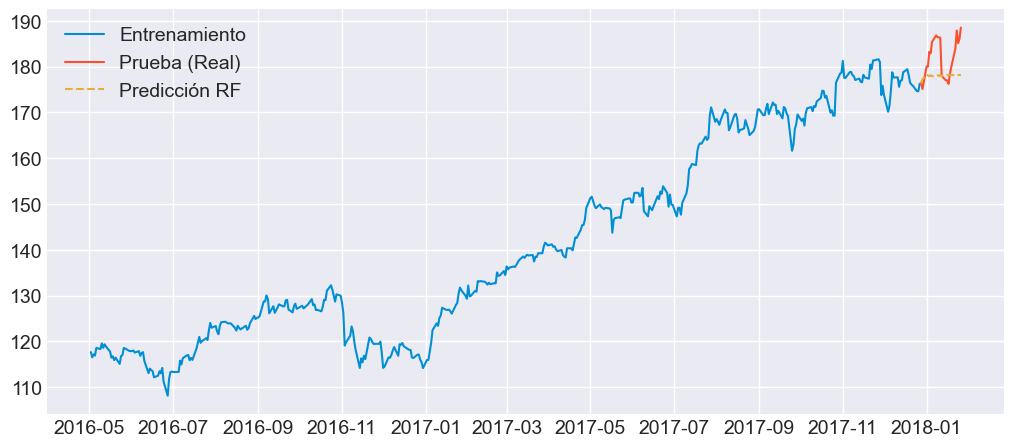

In [28]:
plt.figure(figsize=(11, 5))
plt.plot(data_train.index, data_train['META'], label='Entrenamiento')
plt.plot(data_test.index, data_test['META'], label='Prueba (Real)')
plt.plot(data_test.index, predictions, label='Predicción RF', linestyle='--')
plt.legend()
plt.show()